# 06 — Classification: Automated Scan Quality Control
## Machine Learning in SPM Tutorial
*RMS AFM & SPM Meeting 2026*

## Goals

By the end of this notebook you will be able to:

- Understand **classification** — predicting a category (good vs. bad scan)
- Train a **logistic-regression** baseline and visualise its decision boundary
- Train a **random forest** and evaluate it properly with a confusion matrix and precision/recall
- Understand why **accuracy alone is misleading**, especially with class imbalance

## Why classification for SPM?

A huge amount of SPM time is spent triaging data: *is this scan usable?* *did the tip crash?*
*is this region contaminated?* Done by hand on hundreds of images it is slow and inconsistent.
A classifier trained on a few labelled examples can flag bad scans automatically and consistently.

In [ ]:
# --- Colab bootstrap: clone the repo & install deps when running on Google Colab ---
# (Does nothing when you run locally from the cloned repo.)
import os, sys
if 'google.colab' in sys.modules:
    if not os.path.exists('RMS-AFM-SPM-Meeting-2026'):
        !git clone -q https://github.com/Liambcollins/RMS-AFM-SPM-Meeting-2026.git
    %cd RMS-AFM-SPM-Meeting-2026/notebooks
    !pip -q install scikit-image >/dev/null 2>&1
    print('Colab setup complete.')

In [1]:
import sys, os
sys.path.insert(0, os.path.join('..', 'src'))
import numpy as np
import matplotlib.pyplot as plt
from viz.plotting import set_style
set_style()
print("Setup complete.")
from synthetic.generators import make_scan_quality_dataset

Setup complete.


2-D feature set: ['line_noise', 'feature_contrast']
full feature set: ['line_noise', 'feature_contrast', 'drift', 'fft_sharpness']
class balance (fraction bad): 0.5


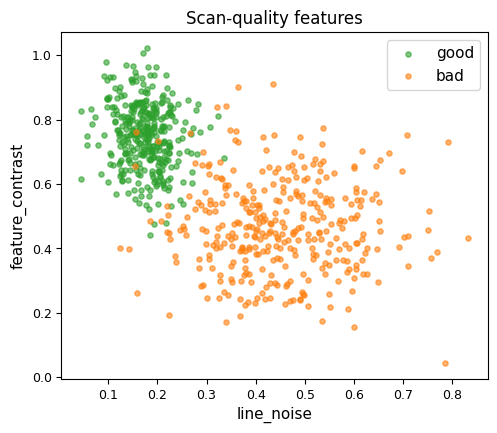

In [2]:
X2, X4, y, names = make_scan_quality_dataset(n_samples=700, random_state=1)
print("2-D feature set:", names[:2])
print("full feature set:", names)
print("class balance (fraction bad):", round(float(y.mean()), 2))

fig, ax = plt.subplots(figsize=(5.5, 4.5))
for cls, color, label in [(0, 'C2', 'good'), (1, 'C1', 'bad')]:
    m = y == cls
    ax.scatter(X2[m, 0], X2[m, 1], s=14, c=color, alpha=0.6, label=label)
ax.set_xlabel(names[0]); ax.set_ylabel(names[1]); ax.set_title('Scan-quality features'); ax.legend()
plt.show()

## Logistic regression — a linear baseline

Logistic regression draws a **straight** decision boundary. It is fast, interpretable, and a great
first model. Always standardise features first so the model treats them on equal footing.

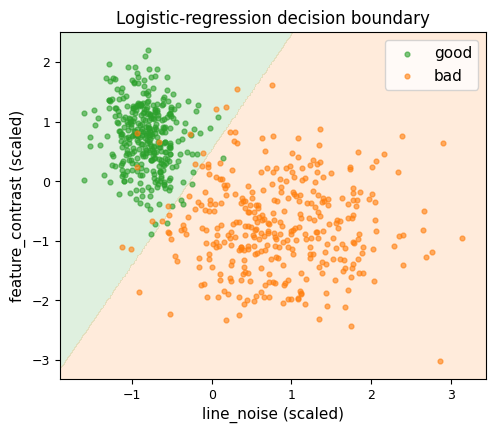

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

scaler = StandardScaler().fit(X2)
Xs = scaler.transform(X2)
X_tr, X_te, y_tr, y_te = train_test_split(Xs, y, test_size=0.3, random_state=0, stratify=y)
logreg = LogisticRegression().fit(X_tr, y_tr)

xx, yy = np.meshgrid(np.linspace(Xs[:,0].min()-.3, Xs[:,0].max()+.3, 250),
                     np.linspace(Xs[:,1].min()-.3, Xs[:,1].max()+.3, 250))
Z = logreg.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.contourf(xx, yy, Z, alpha=0.15, levels=[-.5,.5,1.5], colors=['C2','C1'])
for cls, color, label in [(0,'C2','good'), (1,'C1','bad')]:
    m = y == cls
    ax.scatter(Xs[m,0], Xs[m,1], s=12, c=color, alpha=0.6, label=label)
ax.set_xlabel(names[0]+' (scaled)'); ax.set_ylabel(names[1]+' (scaled)')
ax.set_title('Logistic-regression decision boundary'); ax.legend(); plt.show()

## Random forest + proper evaluation

A random forest can capture non-linear boundaries and use all four features. We evaluate it with a
**confusion matrix** and a **classification report** — never accuracy alone.

              precision    recall  f1-score   support

        good       0.99      0.97      0.98       105
         bad       0.97      0.99      0.98       105

    accuracy                           0.98       210
   macro avg       0.98      0.98      0.98       210
weighted avg       0.98      0.98      0.98       210



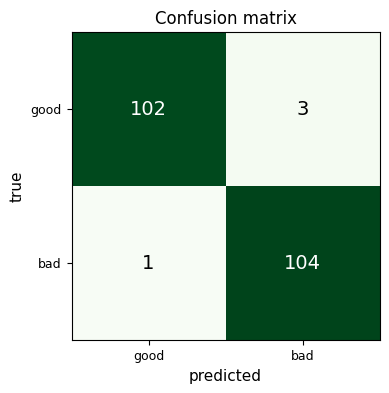

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

scaler4 = StandardScaler().fit(X4)
Xs4 = scaler4.transform(X4)
X_tr, X_te, y_tr, y_te = train_test_split(Xs4, y, test_size=0.3, random_state=0, stratify=y)
rf = RandomForestClassifier(n_estimators=200, random_state=0).fit(X_tr, y_tr)
pred = rf.predict(X_te)

print(classification_report(y_te, pred, target_names=['good','bad']))
cm = confusion_matrix(y_te, pred)
fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(cm, cmap='Greens')
for (i, j), v in np.ndenumerate(cm):
    ax.text(j, i, str(v), ha='center', va='center',
            color='white' if v > cm.max()/2 else 'k', fontsize=14)
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(['good','bad']); ax.set_yticklabels(['good','bad'])
ax.set_xlabel('predicted'); ax.set_ylabel('true'); ax.set_title('Confusion matrix'); plt.show()

## Watch out for class imbalance

If 99% of scans are good, a model that blindly predicts *"good"* every time is 99% accurate — and
completely useless, because it never catches a tip crash. That is why we report **precision and recall**
for the rare class, and use **stratified splits** (note `stratify=y` above) or class weights when training.

## Takeaways

- **Classification predicts categories.** Good/bad, phase A/B/C, crash/clean.
- **Start linear** (logistic regression) for an interpretable baseline, then try a random forest for non-linear structure.
- **Standardise features** and use a **stratified train/test split**.
- **Never trust accuracy alone** — read the confusion matrix and per-class precision/recall, especially when classes are imbalanced.